# NB05b: Formulation Optimization — Strict FDA Safety Filter

**Project**: CF Protective Microbiome Formulation Design  
**Motivation**: NB05 identified top formulations dominated by *Leclercia adecarboxylata* (opportunistic pathogen, Enterobacteriaceae), non-aeruginosa *Pseudomonas* spp. (uncertain FDA status), and *S. epidermidis* (nosocomial risk). These organisms achieve high inhibition but are not viable for a clinical LBP.

This notebook re-runs the optimization with a **strict safety filter** that excludes:
- All Enterobacteriaceae (Leclercia, Citrobacter, Serratia, Escherichia, Enterobacter, Klebsiella)
- All Pseudomonas (including non-aeruginosa species)
- Acinetobacter, Stenotrophomonas, Burkholderia, Achromobacter, Ralstonia
- Bacillus cereus group
- Staphylococcus aureus (S. epidermidis retained as borderline — flagged)

This preserves the NB05 results for comparison and shows the staged decision process.

**Input**: `data/single_isolate_scores.tsv`, `data/species_engraftability.tsv`  
**Output**: `data/formulations_strict_safety.tsv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'
GOLD = Path.home() / 'protect' / 'gold'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

scores = pd.read_csv(DATA / 'single_isolate_scores.tsv', sep='\t')
engraft = pd.read_csv(DATA / 'species_engraftability.tsv', sep='\t', index_col=0)
bridge = pd.read_parquet(GOLD / 'bridge_isolate_metagenomics.snappy.parquet')
isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')
nb05 = pd.read_csv(DATA / 'formulations_ranked.tsv', sep='\t')

print(f'NB05 formulations (permissive filter): {len(nb05)}')
print(f'Isolates with scores: {len(scores)}')

NB05 formulations (permissive filter): 22389
Isolates with scores: 429


## 1. Strict Safety Filter

Exclude all genera with opportunistic pathogen risk. The goal is an FDA-approvable live biotherapeutic product.

In [2]:
# Strict unsafe genera — expanded from NB05
unsafe_genera_strict = [
    # Gram-negative pathogens / opportunists
    'Pseudomonas', 'Pseudomonas_E',   # all Pseudomonas including non-aeruginosa
    'Klebsiella', 'Acinetobacter',
    'Serratia', 'Serratia_J',
    'Citrobacter', 'Citrobacter_B',
    'Enterobacter',
    'Escherichia',
    'Leclercia',                       # Enterobacteriaceae opportunist
    'Stenotrophomonas',
    'Burkholderia',
    'Achromobacter',
    'Ralstonia', 'Ralstonia_B',
    'Moraxella',                       # respiratory opportunist
    # Gram-positive concerns
    'Bacillus_A',                      # B. cereus group
    'Staphylococcus',                  # exclude all Staph (aureus + epidermidis nosocomial)
]

# Also flag specific species even if genus is OK
unsafe_species = [
    'Enterococcus faecalis',           # VRE risk
    'Streptococcus pneumoniae',        # pathogen
    'Streptococcus anginosus',         # abscess-forming
]

scores['strict_safe'] = (
    ~scores.genus.isin(unsafe_genera_strict) & 
    ~scores.species.isin(unsafe_species)
)

# Compare filters
print('=== Filter Comparison ===')
print(f'Total isolates with CU data:    {len(scores)}')
print(f'NB05 permissive safe:           {scores.is_safe.sum()}')
print(f'NB05b strict safe:              {scores.strict_safe.sum()}')
print(f'Removed by strict filter:       {scores.is_safe.sum() - scores.strict_safe.sum()}')

# What did we lose?
lost = scores[scores.is_safe & ~scores.strict_safe & scores.has_inhibition]
print(f'\nIsolates lost from inhibition pool: {len(lost)}')
print(f'Species lost:')
print(lost.groupby('genus').agg(
    n=('asma_id','count'),
    best_inh=('best_pct_inhibition','max')
).sort_values('best_inh', ascending=False).to_string())

=== Filter Comparison ===
Total isolates with CU data:    429
NB05 permissive safe:           387
NB05b strict safe:              341
Removed by strict filter:       46

Isolates lost from inhibition pool: 24
Species lost:
                 n    best_inh
genus                         
Leclercia        1  101.603699
Staphylococcus  15   99.051453
Pseudomonas_E    3   94.311568
Achromobacter    2   36.031041
Moraxella        1   22.207358
Streptococcus    2   10.925831


In [3]:
# Strict-safe candidates with inhibition data
strict_cands = scores[
    (scores.strict_safe == True) & 
    (scores.has_inhibition == True) & 
    (scores.best_pct_inhibition > 0)
].copy()

# Add engraftability
species_engraft_map = {}
for _, row in bridge.iterrows():
    taxon = row['isolate_taxon']
    metag_feat = row['metagenomic_feature']
    if metag_feat in engraft.index:
        species_engraft_map[taxon] = engraft.loc[metag_feat, 'engraftability']
strict_cands['engraftability'] = strict_cands.species.map(species_engraft_map).fillna(0)

print(f'Strict-safe candidates: {len(strict_cands)} isolates, {strict_cands.species.nunique()} species')
print(f'\nTop 20 by inhibition:')
print(strict_cands.nlargest(20, 'best_pct_inhibition')[
    ['asma_id','species','best_pct_inhibition','metabolic_overlap_pa14','engraftability']
].round(3).to_string(index=False))

Strict-safe candidates: 97 isolates, 44 species

Top 20 by inhibition:
  asma_id                  species  best_pct_inhibition  metabolic_overlap_pa14  engraftability
 ASMA-737 Streptococcus salivarius               98.303                   0.247           0.172
ASMA-3643         Neisseria mucosa               87.832                   0.251           1.595
ASMA-3044        Gemella sanguinis               85.014                   0.194           0.202
ASMA-2935      Rothia dentocariosa               79.363                   0.254           0.422
ASMA-2255      Bacillus velezensis               75.434                   0.322           0.000
ASMA-2260   Bacillus licheniformis               68.425                   0.399           0.000
ASMA-2940         Actinomyces oris               65.325                   0.199           0.000
ASMA-1064 Streptococcus salivarius               63.867                   0.193           0.172
 APA20015                      NaN               58.771          

## 2. Re-run Formulation Scoring with Strict Filter

Same scoring function as NB05 but with increased engraftability weight (30% vs 20%) to penalize organisms not found in patient microbiomes.

In [4]:
pa14_preferred = ['proline', 'histidine', 'ornithine', 'glutamate', 'aspartate',
                  'isoleucine', 'arginine', 'lactate', 'leucine', 'alanine', 'glucose']
carbon_sources = ['glucose', 'lactate', 'serine', 'threonine', 'alanine',
                  'glycine', 'proline', 'isoleucine', 'leucine', 'valine', 'aspartate',
                  'glutamate', 'phenylalanine', 'tryptophan', 'lysine', 'histidine',
                  'arginine', 'ornithine', 'cystein', 'methionine']

def score_formulation_v2(isolate_ids, cands_df, growth_threshold=0.1):
    """Score formulation with increased engraftability weight."""
    members = cands_df[cands_df.asma_id.isin(isolate_ids)]
    if len(members) == 0:
        return None
    
    covered = sum(1 for sub in pa14_preferred if (members[sub] > growth_threshold).any())
    niche_coverage = covered / len(pa14_preferred)
    
    if len(members) >= 2:
        profiles = members[carbon_sources].values.astype(float)
        sim = cosine_similarity(profiles)
        n = len(profiles)
        triu = np.triu_indices(n, k=1)
        complementarity = 1 - sim[triu].mean()
    else:
        complementarity = 1.0
    
    mean_inh = members.best_pct_inhibition.mean() / 100
    
    eng_vals = np.maximum(members.engraftability.values, 0.01)
    geo_eng = np.exp(np.mean(np.log(eng_vals)))
    
    species_list = [str(s) if pd.notna(s) else 'Unknown' for s in members.species.values]
    
    # Rebalanced weights: more engraftability, less complementarity
    composite = (0.25 * niche_coverage + 
                 0.10 * complementarity + 
                 0.35 * mean_inh + 
                 0.30 * min(geo_eng, 1.0))
    
    return {
        'isolates': ','.join(sorted(isolate_ids)),
        'k': len(isolate_ids),
        'niche_coverage': niche_coverage,
        'complementarity': complementarity,
        'mean_inhibition': mean_inh * 100,
        'geo_engraftability': geo_eng,
        'composite_score': composite,
        'species': '; '.join(species_list)
    }

print(f'Scoring function v2 defined (weights: coverage=25%, compl=10%, inh=35%, engraft=30%)')

Scoring function v2 defined (weights: coverage=25%, compl=10%, inh=35%, engraft=30%)


In [5]:
# Score formulations — use broader candidate pool for larger k since pool is smaller
top50 = strict_cands.nlargest(50, 'composite_score')
top30 = strict_cands.nlargest(30, 'composite_score')

results = []

# k=1
print('Scoring k=1...')
for _, row in strict_cands.iterrows():
    r = score_formulation_v2([row.asma_id], strict_cands)
    if r: results.append(r)

# k=2: top 50
print('Scoring k=2...')
for combo in combinations(top50.asma_id.values, 2):
    r = score_formulation_v2(list(combo), strict_cands)
    if r: results.append(r)

# k=3: top 30
print('Scoring k=3...')
for combo in combinations(top30.asma_id.values, 3):
    r = score_formulation_v2(list(combo), strict_cands)
    if r: results.append(r)

# k=4-5: top 20
top20 = strict_cands.nlargest(20, 'composite_score')
print('Scoring k=4...')
for combo in combinations(top20.asma_id.values, 4):
    r = score_formulation_v2(list(combo), strict_cands)
    if r: results.append(r)
print('Scoring k=5...')
for combo in combinations(top20.asma_id.values, 5):
    r = score_formulation_v2(list(combo), strict_cands)
    if r: results.append(r)

strict_forms = pd.DataFrame(results)
print(f'\nTotal formulations: {len(strict_forms)}')
for k in range(1, 6):
    fk = strict_forms[strict_forms.k == k]
    if len(fk) > 0:
        print(f'  k={k}: {len(fk)} formulations, best={fk.composite_score.max():.3f}')

Scoring k=1...
Scoring k=2...


Scoring k=3...


Scoring k=4...


Scoring k=5...



Total formulations: 25731
  k=1: 97 formulations, best=0.753
  k=2: 1225 formulations, best=0.588
  k=3: 4060 formulations, best=0.562
  k=4: 4845 formulations, best=0.578
  k=5: 15504 formulations, best=0.587


In [6]:
# Top formulations per size
for k in range(1, 6):
    fk = strict_forms[strict_forms.k == k].nlargest(5, 'composite_score')
    if len(fk) == 0:
        continue
    print(f'\n{"="*90}')
    print(f'  k={k}: Top 5 STRICT-SAFE Formulations')
    print(f'{"="*90}')
    for rank, (_, row) in enumerate(fk.iterrows(), 1):
        print(f'  #{rank}  Composite={row.composite_score:.3f}  Coverage={row.niche_coverage:.0%}  '
              f'Compl={row.complementarity:.2f}  Inh={row.mean_inhibition:.0f}%  '
              f'Engraft={row.geo_engraftability:.3f}')
        print(f'       {row.species}')


  k=1: Top 5 STRICT-SAFE Formulations
  #1  Composite=0.753  Coverage=18%  Compl=1.00  Inh=88%  Engraft=1.595
       Neisseria mucosa
  #2  Composite=0.527  Coverage=9%  Compl=1.00  Inh=79%  Engraft=0.422
       Rothia dentocariosa
  #3  Composite=0.519  Coverage=9%  Compl=1.00  Inh=98%  Engraft=0.172
       Streptococcus salivarius
  #4  Composite=0.503  Coverage=55%  Compl=1.00  Inh=75%  Engraft=0.010
       Bacillus velezensis
  #5  Composite=0.491  Coverage=73%  Compl=1.00  Inh=59%  Engraft=0.010
       Unknown

  k=2: Top 5 STRICT-SAFE Formulations
  #1  Composite=0.588  Coverage=18%  Compl=0.04  Inh=84%  Engraft=0.820
       Rothia dentocariosa; Neisseria mucosa
  #2  Composite=0.545  Coverage=18%  Compl=0.09  Inh=54%  Engraft=1.412
       Rothia aeria; Neisseria mucosa
  #3  Composite=0.531  Coverage=18%  Compl=0.03  Inh=93%  Engraft=0.524
       Neisseria mucosa; Streptococcus salivarius
  #4  Composite=0.531  Coverage=18%  Compl=0.09  Inh=51%  Engraft=1.412
       Rothia aeri

## 3. Compare Permissive vs Strict Filters

In [7]:
# Side-by-side comparison
print(f'{"":30s} {"Permissive (NB05)":>20s}  {"Strict (NB05b)":>20s}')
print('-' * 75)
for k in range(1, 6):
    perm = nb05[nb05.k == k]
    strict = strict_forms[strict_forms.k == k]
    if len(perm) > 0 and len(strict) > 0:
        print(f'k={k} best composite:       {perm.composite_score.max():>20.3f}  {strict.composite_score.max():>20.3f}')
        print(f'k={k} best inhibition (%):  {perm.mean_inhibition.max():>20.0f}  {strict.mean_inhibition.max():>20.0f}')
        print(f'k={k} best coverage:        {perm.niche_coverage.max():>20.0%}  {strict.niche_coverage.max():>20.0%}')
        print(f'k={k} best engraftability:  {perm.geo_engraftability.max():>20.3f}  {strict.geo_engraftability.max():>20.3f}')
        print()

                                  Permissive (NB05)        Strict (NB05b)
---------------------------------------------------------------------------
k=1 best composite:                      0.755                 0.753
k=1 best inhibition (%):                   102                    98
k=1 best coverage:                        100%                  100%
k=1 best engraftability:                 1.595                 1.595

k=2 best composite:                      0.659                 0.588
k=2 best inhibition (%):                   100                    93
k=2 best coverage:                        100%                  100%
k=2 best engraftability:                 0.830                 1.412

k=3 best composite:                      0.650                 0.562
k=3 best inhibition (%):                   100                    90
k=3 best coverage:                        100%                  100%
k=3 best engraftability:                 0.514                 0.662

k=4 best composite:

Species frequency in top 10 strict-safe formulations per size:
species
Neisseria mucosa            36
Micrococcus luteus          31
Streptococcus salivarius    28
Rothia dentocariosa         19
Gemella sanguinis           16
Neisseria sp000186165        6
Bacillus velezensis          4
Rothia aeria                 4
Unknown                      3
Bacillus licheniformis       2
Actinomyces oris_A           1


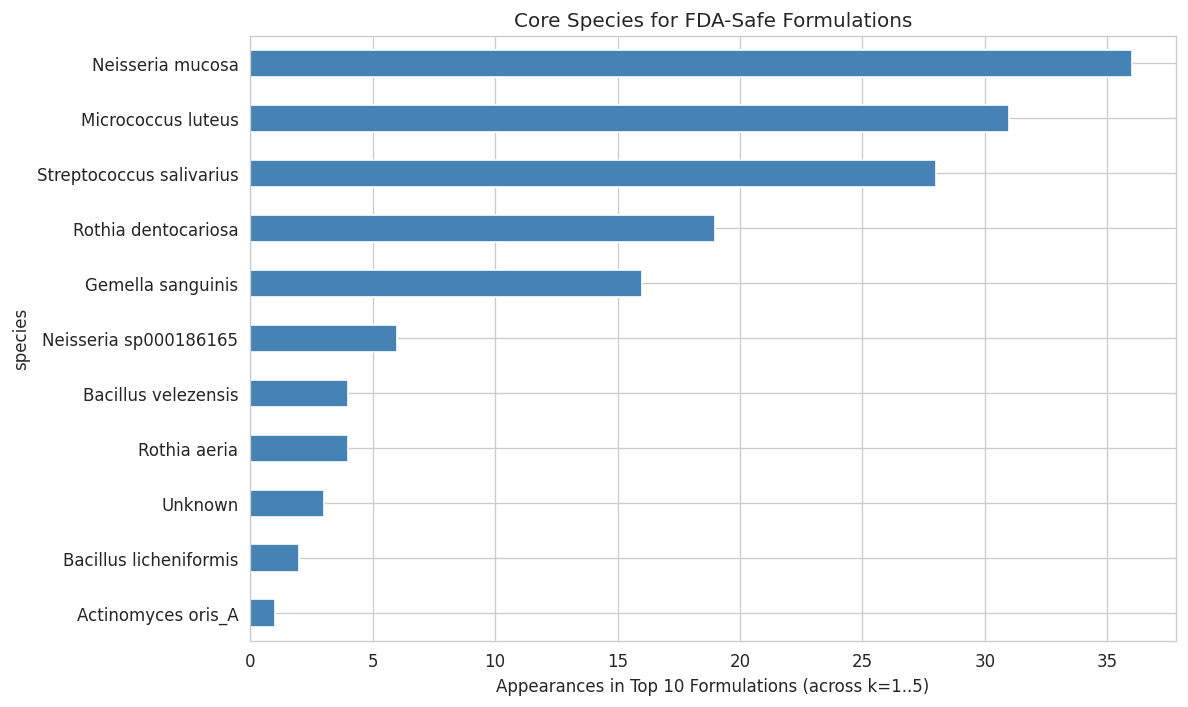

In [8]:
# Species frequency in strict-safe top formulations
all_top = []
for k in range(1, 6):
    top10 = strict_forms[strict_forms.k == k].nlargest(10, 'composite_score')
    for _, row in top10.iterrows():
        for sp in row.species.split('; '):
            all_top.append({'species': sp.strip()})
freq = pd.DataFrame(all_top).groupby('species').size().sort_values(ascending=False)

print('Species frequency in top 10 strict-safe formulations per size:')
print(freq.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
freq.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Appearances in Top 10 Formulations (across k=1..5)')
ax.set_title('Core Species for FDA-Safe Formulations')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGS / '05b_strict_safe_species_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Save
strict_forms.to_csv(DATA / 'formulations_strict_safety.tsv', sep='\t', index=False)
print(f'Saved: {DATA}/formulations_strict_safety.tsv ({len(strict_forms)} formulations)')

print(f'\n{"="*60}')
print('NB05b SUMMARY')
print(f'{"="*60}')
print(f'Permissive pool (NB05): {len(scores[scores.is_safe & scores.has_inhibition & (scores.best_pct_inhibition > 0)])} isolates')
print(f'Strict pool (NB05b):    {len(strict_cands)} isolates ({strict_cands.species.nunique()} species)')
print(f'Formulations scored:    {len(strict_forms)}')
print(f'\nDesign implication: strict safety reduces inhibition ceiling but reveals')
print(f'the organisms that are both effective AND clinically viable.')

Saved: ../data/formulations_strict_safety.tsv (25731 formulations)

NB05b SUMMARY
Permissive pool (NB05): 120 isolates
Strict pool (NB05b):    97 isolates (44 species)
Formulations scored:    25731

Design implication: strict safety reduces inhibition ceiling but reveals
the organisms that are both effective AND clinically viable.
